In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("zurich_electricity_consumption.csv")

df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp")

In [3]:
TARGET_COL = "Value_NE5"
TEMP_COL = "T [°C]"
HUMIDITY_COL = "Hr [%Hr]"

In [4]:
df["hour"] = df["Timestamp"].dt.hour
df["weekday"] = df["Timestamp"].dt.day_name()
df["month"] = df["Timestamp"].dt.month
df["month_name"] = df["Timestamp"].dt.month_name()
df["season"] = df["month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall"
})

In [5]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

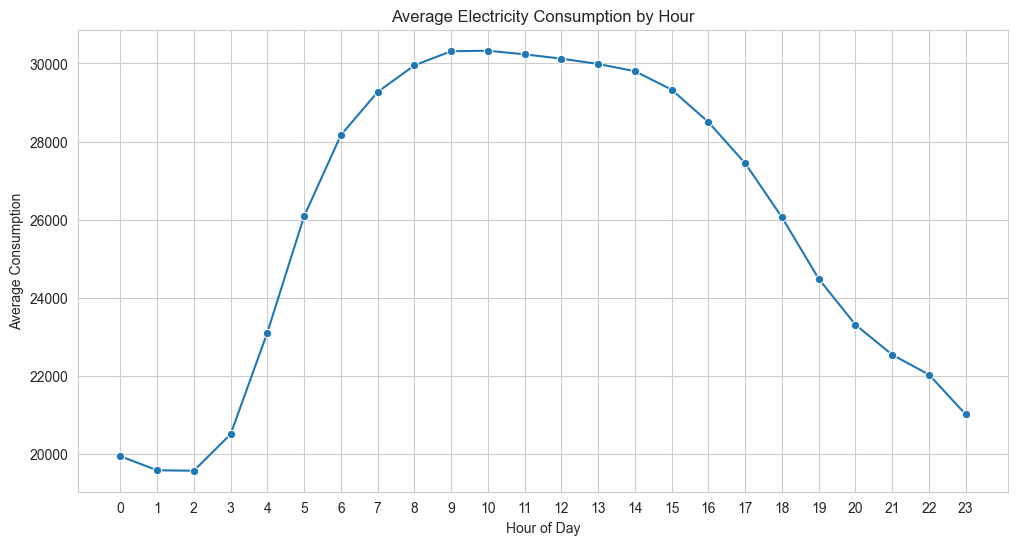

In [ ]:
# ------------------------------------------
# Average by Hour of Day
# ------------------------------------------
hourly_avg = df.groupby("hour")[TARGET_COL].mean()

plt.figure()
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values, marker="o")
plt.title("Average Electricity Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption")
plt.xticks(range(0,24))
plt.show()

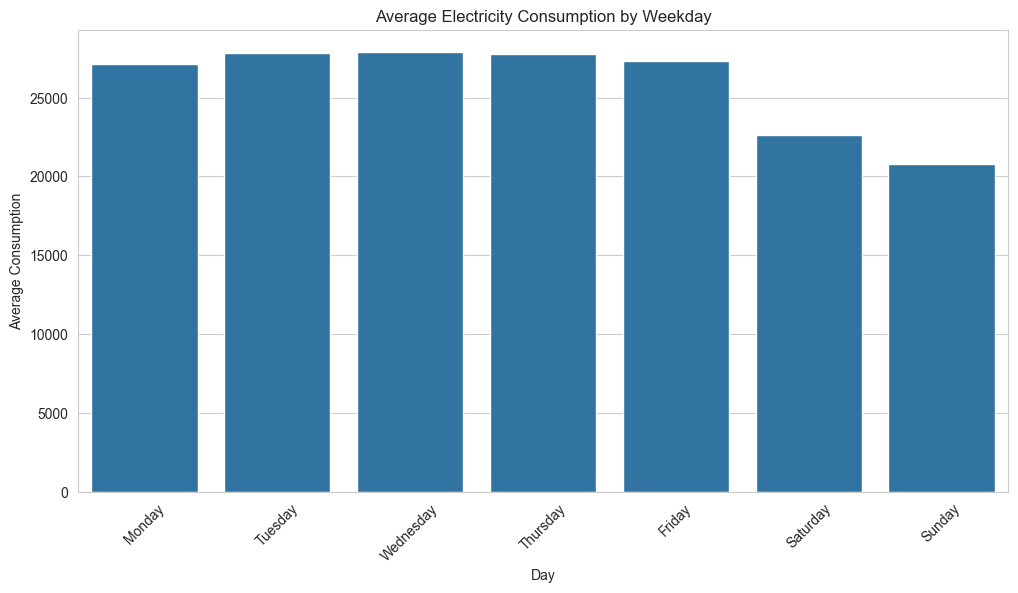

In [ ]:
# ------------------------------------------
# Average by Weekday
# ------------------------------------------
weekday_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

weekday_avg = df.groupby("weekday")[TARGET_COL].mean().reindex(weekday_order)

plt.figure()
sns.barplot(x=weekday_avg.index, y=weekday_avg.values)
plt.title("Average Electricity Consumption by Weekday")
plt.xlabel("Day")
plt.ylabel("Average Consumption")
plt.xticks(rotation=45)
plt.show()

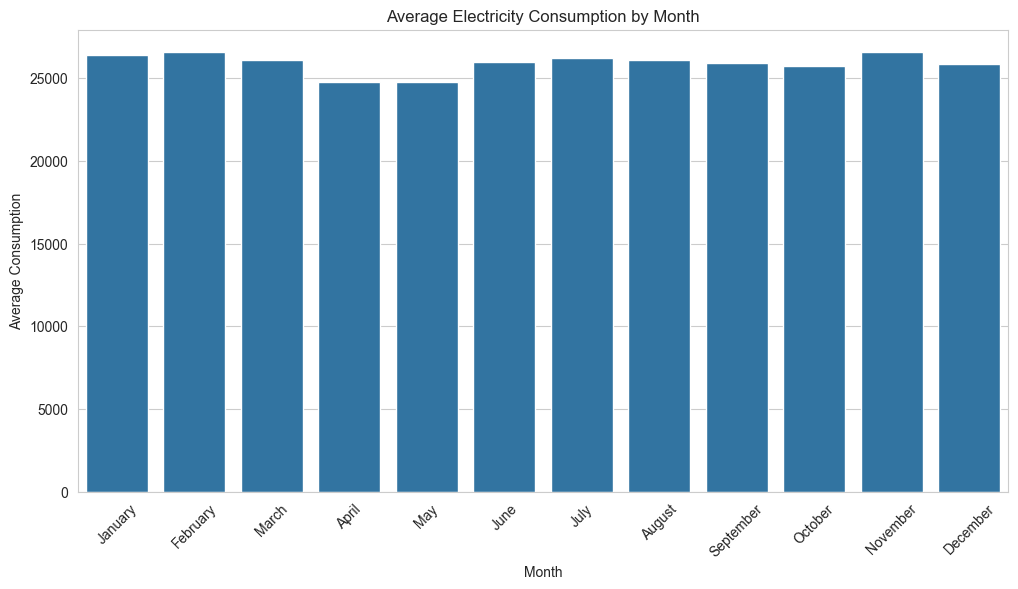

In [ ]:
# ------------------------------------------
# Monthly Averages
# ------------------------------------------
monthly_avg = df.groupby("month_name")[TARGET_COL].mean()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_avg = monthly_avg.reindex(month_order)

plt.figure()
sns.barplot(x=monthly_avg.index, y=monthly_avg.values)
plt.title("Average Electricity Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Consumption")
plt.xticks(rotation=45)
plt.show()

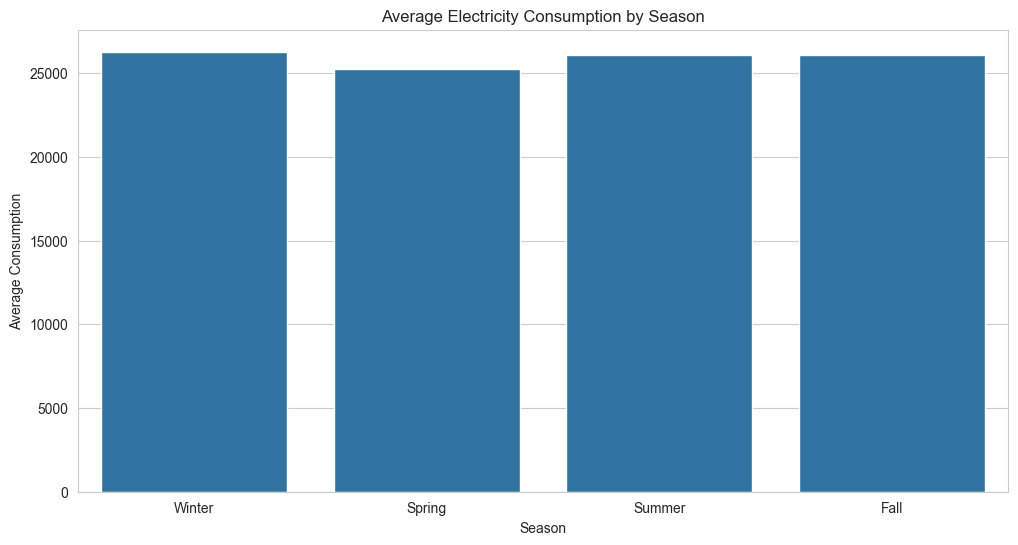

In [ ]:
# ------------------------------------------
# Seasonal Peaks
# ------------------------------------------
season_avg = df.groupby("season")[TARGET_COL].mean()
season_order = ["Winter","Spring","Summer","Fall"]
season_avg = season_avg.reindex(season_order)

plt.figure()
sns.barplot(x=season_avg.index, y=season_avg.values)
plt.title("Average Electricity Consumption by Season")
plt.xlabel("Season")
plt.ylabel("Average Consumption")
plt.show()

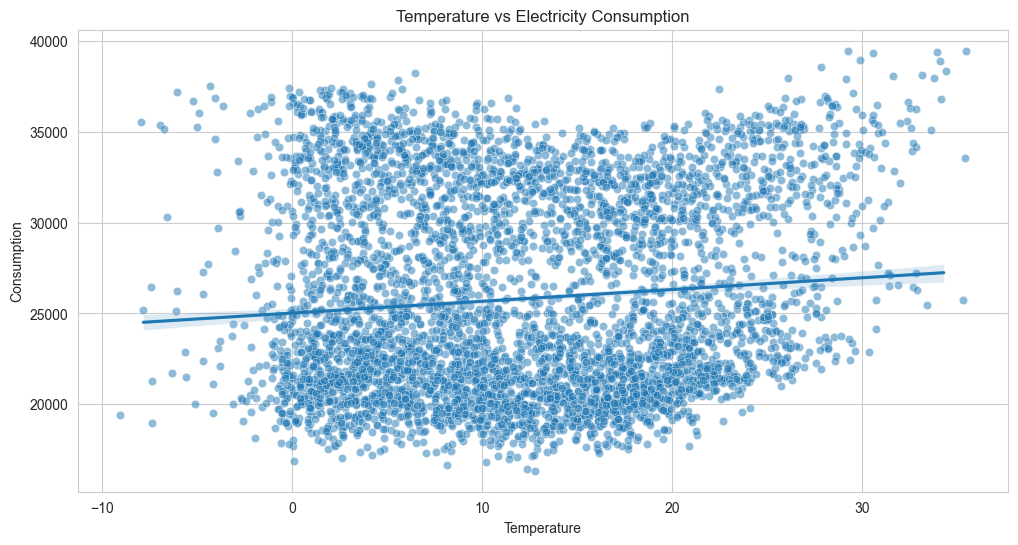

In [ ]:
# ------------------------------------------
# Temperature vs Consumption
# ------------------------------------------
plt.figure()
sns.scatterplot(data=df.sample(min(len(df), 5000)),
                x=TEMP_COL,
                y=TARGET_COL,
                alpha=0.5)

sns.regplot(data=df.sample(min(len(df), 5000)),
            x=TEMP_COL,
            y=TARGET_COL,
            scatter=False)

plt.title("Temperature vs Electricity Consumption")
plt.xlabel("Temperature")
plt.ylabel("Consumption")
plt.show()

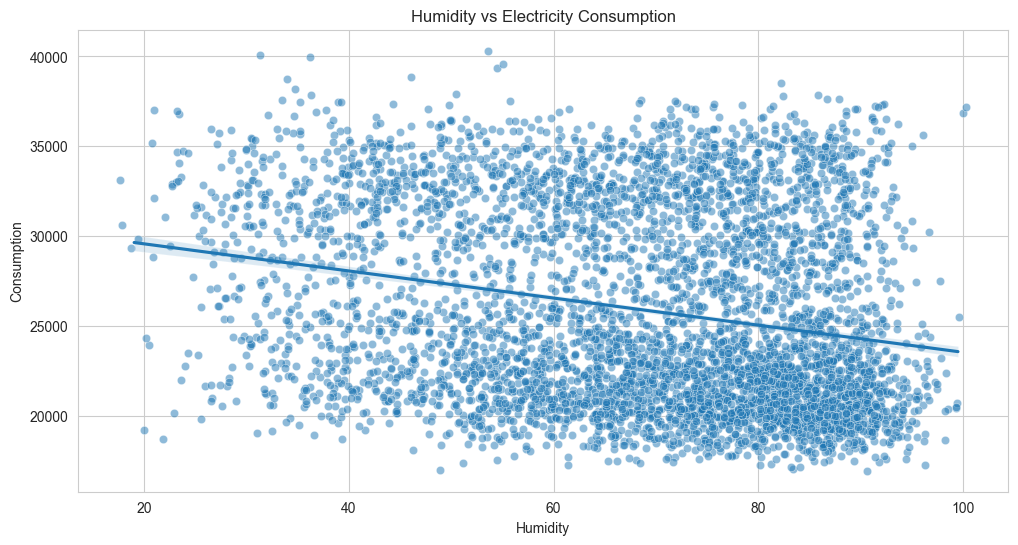

In [ ]:
# ------------------------------------------
# Humidity vs Consumption
# ------------------------------------------
plt.figure()
sns.scatterplot(data=df.sample(min(len(df), 5000)),
                x=HUMIDITY_COL,
                y=TARGET_COL,
                alpha=0.5)

sns.regplot(data=df.sample(min(len(df), 5000)),
            x=HUMIDITY_COL,
            y=TARGET_COL,
            scatter=False)

plt.title("Humidity vs Electricity Consumption")
plt.xlabel("Humidity")
plt.ylabel("Consumption")
plt.show()

           Condition  Avg Consumption
0      Hot (Top 10%)     29405.821579
1  Cold (Bottom 10%)     25884.625043


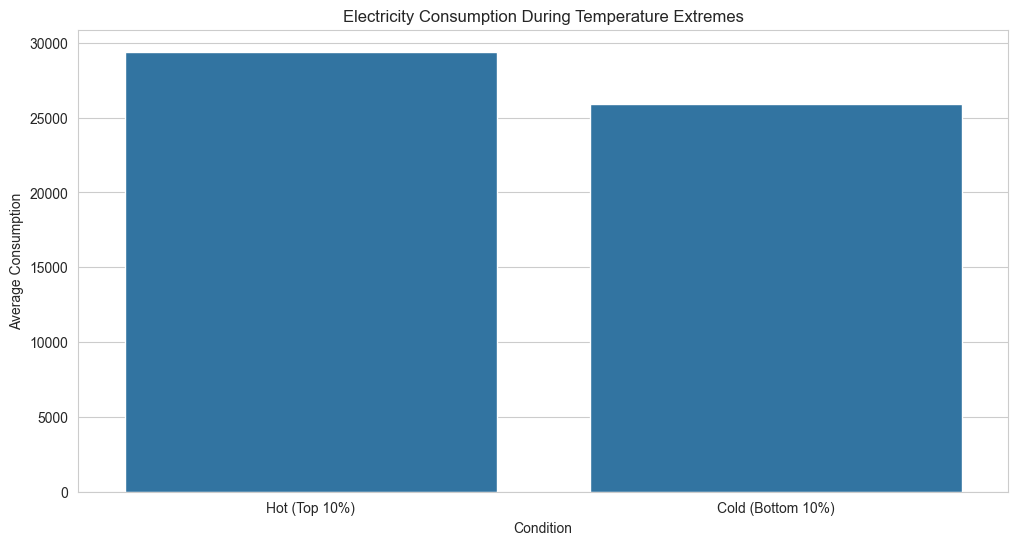

In [ ]:
# ------------------------------------------
# Hot / Cold Extremes
# ------------------------------------------
hot_threshold = df[TEMP_COL].quantile(0.90)
cold_threshold = df[TEMP_COL].quantile(0.10)

hot_days = df[df[TEMP_COL] >= hot_threshold]
cold_days = df[df[TEMP_COL] <= cold_threshold]

summary = pd.DataFrame({
    "Condition": ["Hot (Top 10%)", "Cold (Bottom 10%)"],
    "Avg Consumption": [
        hot_days[TARGET_COL].mean(),
        cold_days[TARGET_COL].mean()
    ]
})

print(summary)

plt.figure()
sns.barplot(data=summary, x="Condition", y="Avg Consumption")
plt.title("Electricity Consumption During Temperature Extremes")
plt.ylabel("Average Consumption")
plt.show()

<Axes: xlabel='Timestamp'>

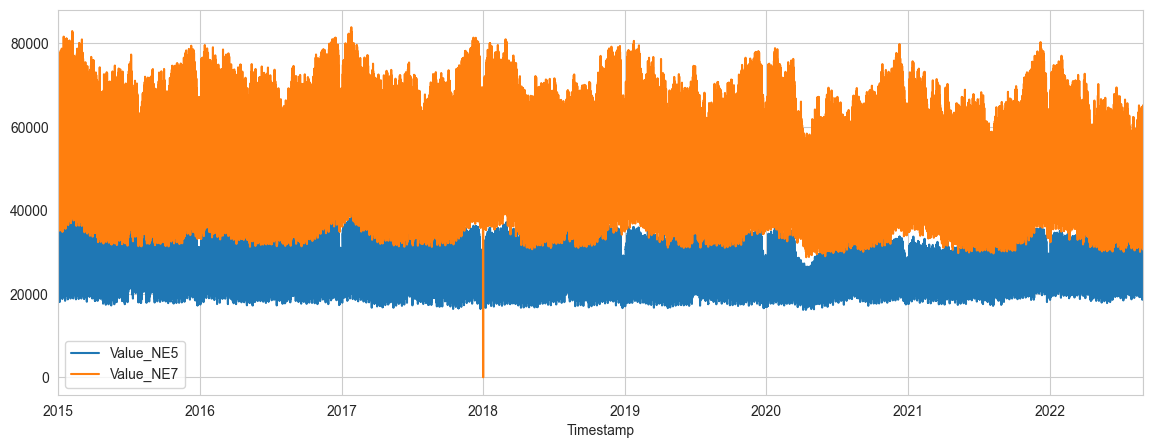

In [ ]:
# ------------------------------------------
# Compare Target Demand Columns
# ------------------------------------------
df.set_index("Timestamp")[['Value_NE5','Value_NE7']].plot(figsize=(14,5))

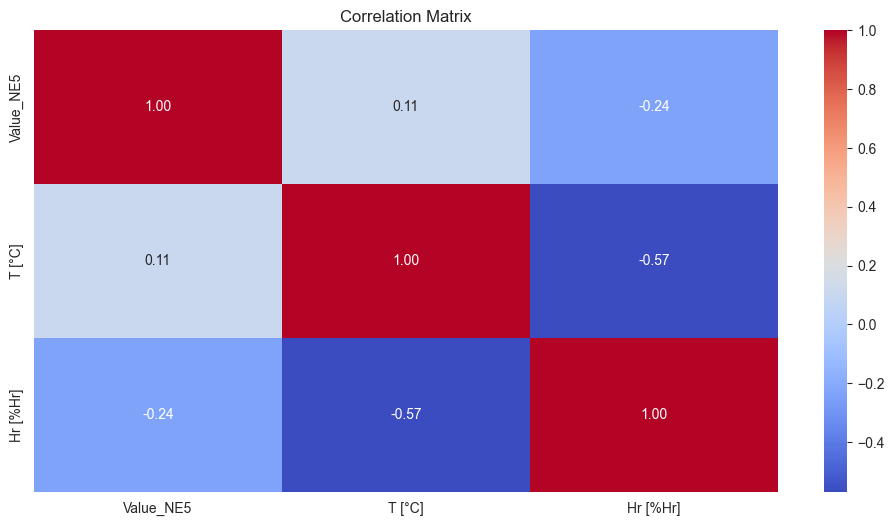

In [ ]:
# ------------------------------------------
# Correlation matrix
# ------------------------------------------
numeric_cols = [TARGET_COL, TEMP_COL, HUMIDITY_COL]

plt.figure()
sns.heatmap(df[numeric_cols].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()